# LAB 02 - Spatial Exploratory Data Analysis

## Sampling density is not spatial signal

This laboratory examines a common problem in geospatial analysis:

> A location with many observations is not necessarily the location with the
> strongest underlying spatial signal.

The experiment uses synthetic data so that the underlying spatial process is
known. This makes it possible to compare sampling density, observed signal,
and synthetic ground truth before predictive modelling.

The workflow follows:

**CRS validation -> sampling-density analysis -> spatial aggregation ->
resolution sensitivity -> interpretation**


## Experimental design

Each synthetic realization contains:

- 500 broadly distributed regional observations;
- 300 observations from an intensive local campaign;
- 800 observations in total.

The intensive campaign and the strongest underlying signal are deliberately
located in different parts of the study region.

All spatial calculations use **EPSG:32719 - WGS 84 / UTM zone 19S**, so
distances and grid dimensions are expressed in metres.


In [1]:
import json
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box


def find_repo_root(start: Path) -> Path:
    current = start.resolve()

    for candidate in (current, *current.parents):
        if (candidate / "src" / "geoai").exists():
            return candidate

    raise RuntimeError(
        "Repository root containing src/geoai was not found."
    )


REPO_ROOT = find_repo_root(Path.cwd())
SRC_DIR = REPO_ROOT / "src"
LAB_DIR = (
    REPO_ROOT
    / "labs"
    / "lab02_spatial_eda"
)
RESULTS_DIR = LAB_DIR / "results"
CONTEXT_DIR = LAB_DIR / "data" / "context"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from geoai.spatial import (
    DEFAULT_BOUNDS,
    DEFAULT_CRS,
    assign_regular_grid,
    generate_synthetic_sampling,
    nearest_neighbor_distances,
    require_metric_projected_crs,
    summarize_grid,
)

PRIMARY_CELL_SIZE_M = 10000.0
GRID_ORIGIN = (
    DEFAULT_BOUNDS[0],
    DEFAULT_BOUNDS[2],
)

print("Primary grid resolution:", PRIMARY_CELL_SIZE_M, "m")


Primary grid resolution: 10000.0 m


## Geographic context of the synthetic experiment

Before analysing sampling density, the synthetic study domain is placed in a
real geographic reference frame.

The country outline comes from **Natural Earth Admin 0 - Countries, 1:110m,
version 5.1.1**. It is used only as a lightweight locator.

The LAB02 study extent, sampling design, spatial signal, observations, and
analytical results remain entirely synthetic.

The projected study domain uses **EPSG:32719 - WGS 84 / UTM zone 19S** and is
transformed to EPSG:4326 only for this geographic-context figure.


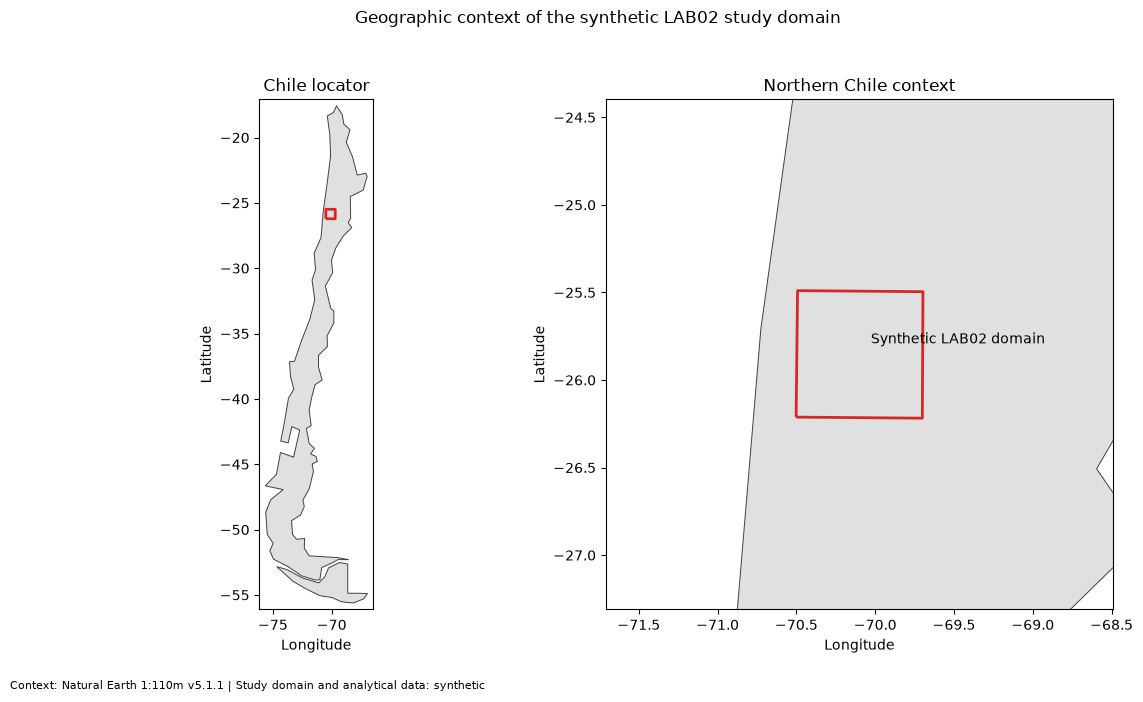

Context source: Natural Earth
Context version: 5.1.1
Synthetic study CRS: EPSG:32719
Study domain within Chile: True
Study bounds in EPSG:4326: (-70.501432, -26.217861, -69.696498, -25.489572)


In [2]:
context_path = (
    CONTEXT_DIR
    / "chile_context.geojson"
)

if not context_path.exists():
    raise FileNotFoundError(
        f"Context layer was not found: {context_path}"
    )

chile_context = gpd.read_file(
    context_path,
    engine="pyogrio",
)

required_context_columns = {
    "name",
    "iso_a2",
    "iso_a3",
    "source",
    "source_dataset",
    "source_scale",
    "source_version",
    "geometry",
}

missing_context_columns = (
    required_context_columns
    - set(chile_context.columns)
)

if missing_context_columns:
    raise ValueError(
        "Context layer is missing required columns: "
        f"{sorted(missing_context_columns)}"
    )

if len(chile_context) != 1:
    raise ValueError(
        "Context layer must contain exactly one country feature."
    )

if chile_context.iloc[0]["iso_a3"] != "CHL":
    raise ValueError(
        "Context layer must represent Chile (ISO_A3 = CHL)."
    )

if chile_context.crs is None:
    raise ValueError(
        "Context layer CRS is missing."
    )

if chile_context.crs.to_epsg() != 4326:
    raise ValueError(
        "Context layer must use EPSG:4326."
    )

if not chile_context.geometry.is_valid.all():
    raise ValueError(
        "Context layer contains invalid geometry."
    )

xmin, xmax, ymin, ymax = DEFAULT_BOUNDS

study_domain_utm = gpd.GeoDataFrame(
    {
        "name": [
            "Synthetic LAB02 study domain",
        ],
    },
    geometry=[
        box(
            xmin,
            ymin,
            xmax,
            ymax,
        )
    ],
    crs=DEFAULT_CRS,
)

study_domain_wgs84 = (
    study_domain_utm
    .to_crs(chile_context.crs)
)

chile_geometry = (
    chile_context
    .geometry
    .iloc[0]
)

study_geometry = (
    study_domain_wgs84
    .geometry
    .iloc[0]
)

if not study_geometry.within(chile_geometry):
    raise ValueError(
        "Synthetic study domain must be fully contained "
        "within the Chile context geometry."
    )

study_bounds = (
    study_domain_wgs84
    .total_bounds
)

country_bounds = (
    chile_context
    .total_bounds
)

study_width = (
    study_bounds[2]
    - study_bounds[0]
)

study_height = (
    study_bounds[3]
    - study_bounds[1]
)

x_margin = max(
    1.5 * study_width,
    1.0,
)

y_margin = max(
    1.5 * study_height,
    1.0,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 7),
)

chile_context.plot(
    ax=axes[0],
    color="0.88",
    edgecolor="0.25",
    linewidth=0.7,
)

study_domain_wgs84.boundary.plot(
    ax=axes[0],
    color="tab:red",
    linewidth=2.0,
)

axes[0].set_title(
    "Chile locator"
)

axes[0].set_xlabel(
    "Longitude"
)

axes[0].set_ylabel(
    "Latitude"
)

axes[0].set_xlim(
    country_bounds[0] - 0.5,
    country_bounds[2] + 0.5,
)

axes[0].set_ylim(
    country_bounds[1] - 0.5,
    country_bounds[3] + 0.5,
)

chile_context.plot(
    ax=axes[1],
    color="0.88",
    edgecolor="0.25",
    linewidth=0.7,
)

study_domain_wgs84.boundary.plot(
    ax=axes[1],
    color="tab:red",
    linewidth=2.0,
)

study_centroid = (
    study_geometry
    .centroid
)

axes[1].annotate(
    "Synthetic LAB02 domain",
    xy=(
        study_centroid.x,
        study_centroid.y,
    ),
    xytext=(8, 8),
    textcoords="offset points",
)

axes[1].set_title(
    "Northern Chile context"
)

axes[1].set_xlabel(
    "Longitude"
)

axes[1].set_ylabel(
    "Latitude"
)

axes[1].set_xlim(
    study_bounds[0] - x_margin,
    study_bounds[2] + x_margin,
)

axes[1].set_ylim(
    study_bounds[1] - y_margin,
    study_bounds[3] + y_margin,
)

fig.suptitle(
    "Geographic context of the synthetic LAB02 study domain"
)

fig.text(
    0.01,
    0.01,
    (
        "Context: Natural Earth 1:110m v5.1.1 | "
        "Study domain and analytical data: synthetic"
    ),
    fontsize=8,
)

plt.tight_layout(
    rect=(0.0, 0.04, 1.0, 0.95)
)

plt.show()

print(
    "Context source:",
    chile_context.iloc[0]["source"],
)

print(
    "Context version:",
    chile_context.iloc[0]["source_version"],
)

print(
    "Synthetic study CRS:",
    DEFAULT_CRS,
)

print(
    "Study domain within Chile:",
    study_geometry.within(chile_geometry),
)

print(
    "Study bounds in EPSG:4326:",
    tuple(
        round(float(value), 6)
        for value in study_bounds
    ),
)


### Context interpretation

The map provides geographic orientation only.

The Chile outline is real public-domain contextual cartography, while the
highlighted LAB02 domain is a synthetic methodological extent.

Its position must not be interpreted as an actual exploration project, mining
property, concession, prospect, deposit, mineral occurrence, or field campaign.

No geographic context layer contributes to the synthetic signal, sampling
density, Monte Carlo experiment, or subsequent spatial analysis.


## 1. Generate the controlled spatial experiment

The default seed is fixed at `12345` for the baseline walkthrough.

The synthetic dataset retains both:

- `signal_true`: the known underlying spatial process;
- `signal`: the observed value after random noise is added.

This distinction would not normally be available with real exploration data,
but it is useful here because it lets us validate the behaviour of the
exploratory workflow.


In [3]:
samples = generate_synthetic_sampling(seed=12345)

crs = require_metric_projected_crs(samples)

print("Observations:", len(samples))
print("CRS:", crs.to_string())
print()
print(samples["sampling_component"].value_counts())
print()
print(samples.head())


Observations: 800
CRS: EPSG:32719

sampling_component
regional    500
campaign    300
Name: count, dtype: int64

  sample_id sampling_component  signal_true     signal  \
0     S0001           regional    10.000000  15.480627   
1     S0002           regional    10.000011   6.262295   
2     S0003           regional    10.000000  12.893035   
3     S0004           regional    10.000000   9.663387   
4     S0005           regional    10.006110   7.958912   

                         geometry  
0  POINT (368186.882 7156688.989)  
1  POINT (375340.667 7178094.878)  
2  POINT (413789.237 7110619.583)  
3  POINT (404100.374 7107708.607)  
4  POINT (381288.764 7166538.805)  


## 2. Visualize the sampling pattern

The first map shows **where observations were collected**, not the magnitude of
the spatial signal.

A dense cluster can therefore represent sampling effort rather than geology.


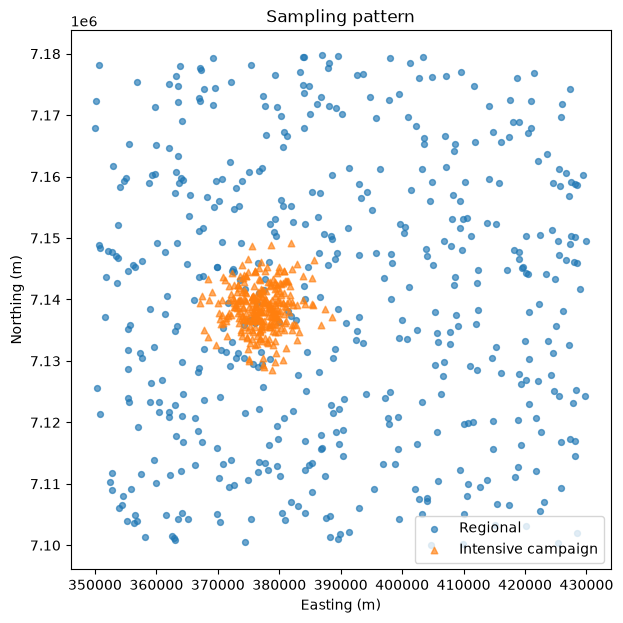

In [4]:
regional = samples[
    samples["sampling_component"] == "regional"
].copy()

campaign = samples[
    samples["sampling_component"] == "campaign"
].copy()

fig, ax = plt.subplots(figsize=(8, 7))

regional.plot(
    ax=ax,
    marker="o",
    markersize=18,
    alpha=0.65,
    label="Regional",
)

campaign.plot(
    ax=ax,
    marker="^",
    markersize=22,
    alpha=0.65,
    label="Intensive campaign",
)

ax.set_title("Sampling pattern")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()
ax.set_aspect("equal")

plt.show()


### Interpretation

The intensive campaign creates an obvious cluster of observations.

If sampling density were interpreted visually without further analysis, this
area could incorrectly appear to be the most important spatial zone.

We therefore quantify sampling density rather than relying only on the map.


## 3. Nearest-neighbour sampling density

Nearest-neighbour distance provides a simple descriptive measure of how tightly
observations are spatially packed.

Shorter distances indicate denser local sampling.


In [5]:
regional_nn = nearest_neighbor_distances(regional)
campaign_nn = nearest_neighbor_distances(campaign)

regional_mean_nn = float(regional_nn.mean())
campaign_mean_nn = float(campaign_nn.mean())
nn_ratio = campaign_mean_nn / regional_mean_nn

nn_summary = pd.DataFrame(
    {
        "Sampling component": [
            "Regional",
            "Intensive campaign",
        ],
        "Mean NN distance (m)": [
            regional_mean_nn,
            campaign_mean_nn,
        ],
    }
)

display(nn_summary.round(2))

print(
    "Campaign / regional NN ratio:",
    round(nn_ratio, 3),
)


,Sampling component,Mean NN distance (m)
0,Regional,1807.35
1,Intensive campaign,502.73


Campaign / regional NN ratio: 0.278


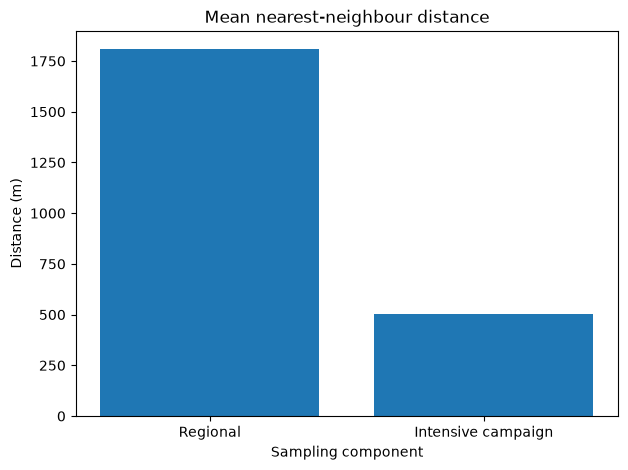

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    nn_summary["Sampling component"],
    nn_summary["Mean NN distance (m)"],
)

ax.set_title("Mean nearest-neighbour distance")
ax.set_ylabel("Distance (m)")
ax.set_xlabel("Sampling component")

plt.show()


### Baseline result

For seed `12345`, the intensive campaign has a much smaller mean
nearest-neighbour distance than the regional observations.

The campaign/regional ratio is approximately **0.278**.

This confirms quantitatively that the campaign area is much more densely
sampled.


## 4. Visualize the observed spatial signal

The next map changes the question.

Instead of showing **where sampling is dense**, it shows the magnitude of the
observed synthetic signal.


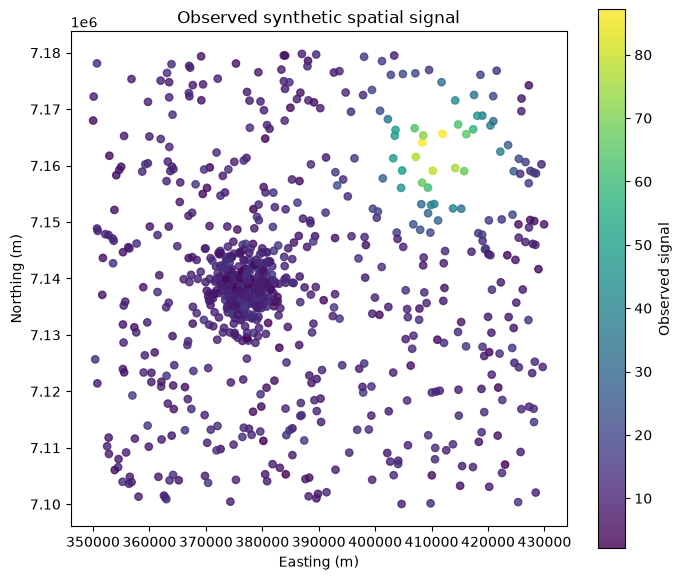

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    samples.geometry.x,
    samples.geometry.y,
    c=samples["signal"],
    s=28,
    alpha=0.8,
)

ax.set_title("Observed synthetic spatial signal")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Observed signal")

plt.show()


## 5. Aggregate observations using the selected grid

Grid aggregation requires a spatial-resolution decision.

LAB 02 evaluates 5 km, 10 km, and 20 km grids using repeated Monte Carlo
realizations and multiple grid origins.

The sensitivity experiment selected **10 km x 10 km** as the primary
descriptive resolution for this synthetic experiment.

This is not a universal recommendation for mineral exploration.


In [8]:
gridded = assign_regular_grid(
    samples,
    cell_size_m=PRIMARY_CELL_SIZE_M,
    origin=GRID_ORIGIN,
)

observed_summary = summarize_grid(
    gridded,
    signal_column="signal",
)

true_summary = summarize_grid(
    gridded,
    signal_column="signal_true",
)

print("Populated cells:", len(observed_summary))
print(
    "Observations preserved:",
    int(observed_summary["observation_count"].sum()),
)


Populated cells: 64
Observations preserved: 800


## 6. Compare sampling density and spatial signal

For the selected 10 km grid we identify:

1. the cell with the greatest number of observations;
2. the cell with the highest observed mean signal;
3. the cell with the highest known true mean signal.


In [9]:
densest_cell = observed_summary.loc[
    observed_summary["observation_count"].idxmax()
]

observed_hotspot = observed_summary.loc[
    observed_summary["mean_signal"].idxmax()
]

true_hotspot = true_summary.loc[
    true_summary["mean_signal"].idxmax()
]

comparison = pd.DataFrame(
    [
        {
            "Feature": "Densest sampling cell",
            "Grid ID": densest_cell["grid_id"],
            "Observations": int(
                densest_cell["observation_count"]
            ),
            "Mean signal": float(
                densest_cell["mean_signal"]
            ),
        },
        {
            "Feature": "Highest observed-signal cell",
            "Grid ID": observed_hotspot["grid_id"],
            "Observations": int(
                observed_hotspot["observation_count"]
            ),
            "Mean signal": float(
                observed_hotspot["mean_signal"]
            ),
        },
        {
            "Feature": "Highest true-signal cell",
            "Grid ID": true_hotspot["grid_id"],
            "Observations": int(
                true_hotspot["observation_count"]
            ),
            "Mean signal": float(
                true_hotspot["mean_signal"]
            ),
        },
    ]
)

display(comparison.round(2))


,Feature,Grid ID,Observations,Mean signal
0,Densest sampling cell,c2_r3,178,10.26
1,Highest observed-signal cell,c6_r6,6,59.19
2,Highest true-signal cell,c6_r6,6,59.89


In [10]:
print(
    "Densest cell differs from observed hotspot:",
    densest_cell["grid_id"] != observed_hotspot["grid_id"],
)

print(
    "Densest cell differs from true hotspot:",
    densest_cell["grid_id"] != true_hotspot["grid_id"],
)

print(
    "Observed hotspot agrees with true hotspot:",
    observed_hotspot["grid_id"] == true_hotspot["grid_id"],
)


Densest cell differs from observed hotspot: True
Densest cell differs from true hotspot: True
Observed hotspot agrees with true hotspot: True


### Baseline interpretation

The densest sampling cell is not the strongest spatial-signal cell.

For the baseline realization, the highest observed-signal cell also agrees with
the known true-signal cell.

This illustrates the main methodological point:

> Sampling effort and spatial signal must be analysed separately.


## 7. Resolution sensitivity

The primary resolution was not chosen from the baseline map.

A separate confirmatory Monte Carlo experiment produced the persisted public artifacts under `results/`. Its design metadata and summary statistics are loaded below.

Grid origin and resolution are repeated evaluations within each realization,
not independent observations.


In [11]:
summary_path = (
    RESULTS_DIR
    / "resolution_summary.csv"
)

metadata_path = (
    RESULTS_DIR
    / "experiment_metadata.json"
)

if not summary_path.exists():
    raise FileNotFoundError(
        "Monte Carlo summary not found. "
        "Expected persisted public artifact under results/."
    )

if not metadata_path.exists():
    raise FileNotFoundError(
        "Experiment metadata not found. "
        "Expected persisted public artifact under results/."
    )

resolution_results = pd.read_csv(
    summary_path
)

with metadata_path.open(
    "r",
    encoding="utf-8",
) as handle:
    experiment_metadata = json.load(handle)

monte_carlo = experiment_metadata[
    "monte_carlo"
]

expected_resolutions = {
    int(value)
    for value in monte_carlo[
        "grid_resolutions_m"
    ]
}

observed_resolutions = {
    int(value)
    for value in resolution_results[
        "cell_size_m"
    ]
}

if observed_resolutions != expected_resolutions:
    raise ValueError(
        "Resolution summary does not match "
        "the experiment metadata."
    )

expected_realizations = int(
    monte_carlo[
        "independent_realizations"
    ]
)

if not (
    resolution_results["n_realizations"]
    == expected_realizations
).all():
    raise ValueError(
        "Resolution summary contains an "
        "unexpected realization count."
    )

print(
    "Independent spatial realizations:",
    expected_realizations,
)
print(
    "Grid resolutions:",
    len(expected_resolutions),
)
print(
    "Offsets per resolution:",
    monte_carlo["offsets_per_resolution"],
)
print(
    "Total grid evaluations:",
    monte_carlo["total_grid_evaluations"],
)

all_offsets_label = (
    "All "
    + str(
        monte_carlo[
            "offsets_per_resolution"
        ]
    )
    + " offsets matching (%)"
)

resolution_summary = pd.DataFrame(
    {
        "Grid (km)": (
            resolution_results[
                "grid_km"
            ]
        ),
        "Mean offset match rate (%)": (
            100.0
            * resolution_results[
                "mean_offset_match_rate"
            ]
        ),
        all_offsets_label: (
            100.0
            * resolution_results[
                "all_offsets_match_rate"
            ]
        ),
        "Median n at true hotspot": (
            resolution_results[
                "median_true_hotspot_n"
            ]
        ),
        "Peak retention (%)": (
            100.0
            * resolution_results[
                "peak_retention_rate"
            ]
        ),
    }
)

display(
    resolution_summary.round(
        {
            "Grid (km)": 0,
            "Mean offset match rate (%)": 1,
            all_offsets_label: 1,
            "Median n at true hotspot": 1,
            "Peak retention (%)": 1,
        }
    )
)


Independent spatial realizations: 400
Grid resolutions: 3
Offsets per resolution: 4
Total grid evaluations: 4800


,Grid (km),Mean offset match rate (%),All 4 offsets matching (%),Median n at true hotspot,Peak retention (%)
0,5.0,87.4,63.0,2.0,94.3
1,10.0,98.8,95.8,7.5,78.8
2,20.0,98.9,95.8,31.5,45.7


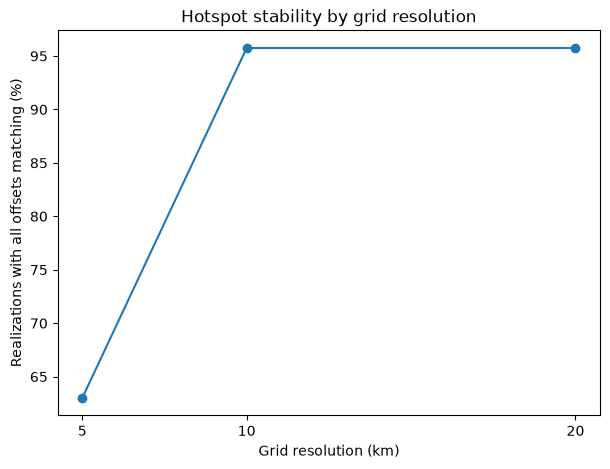

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    resolution_summary["Grid (km)"],
    resolution_summary[
        all_offsets_label
    ],
    marker="o",
)

ax.set_title("Hotspot stability by grid resolution")
ax.set_xlabel("Grid resolution (km)")
ax.set_ylabel("Realizations with all offsets matching (%)")
ax.set_xticks(
    resolution_summary["Grid (km)"]
)

plt.show()


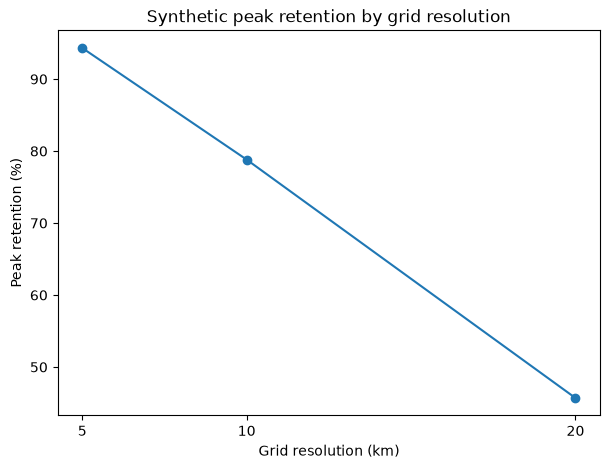

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    resolution_summary["Grid (km)"],
    resolution_summary["Peak retention (%)"],
    marker="o",
)

ax.set_title("Synthetic peak retention by grid resolution")
ax.set_xlabel("Grid resolution (km)")
ax.set_ylabel("Peak retention (%)")
ax.set_xticks(
    resolution_summary["Grid (km)"]
)

plt.show()


## 8. Why 10 km was selected

The tested resolutions show a clear trade-off.

### 5 km

Preserves local signal well, but the hotspot contains only about two
observations and interpretation is sensitive to grid origin.

### 10 km

Provides high hotspot stability, better local sample support, and retains
approximately 79% of the theoretical spatial peak.

### 20 km

Provides high stability and sample support, but retains only about 46% of the
spatial peak, indicating substantial smoothing.

Therefore, **10 km is used as the primary descriptive resolution for this
synthetic experiment**.

It is not proposed as a universal grid size.


## 9. GeoAI relevance

This experiment demonstrates a problem that becomes more important when
predictive models are introduced.

A model such as Random Forest, gradient boosting, XGBoost, or a neural network
may partially learn **where observations were collected most intensively**
instead of learning the underlying geological process.

This is one reason why ordinary random train/test splitting can be misleading
for spatial data.

The next stage of the roadmap therefore introduces **spatial validation and
spatial cross-validation** before predictive mineral-prospectivity modelling.


## 10. Limitations

This laboratory deliberately isolates one methodological problem.

It does not yet include:

- real geological observations;
- lithological or structural controls;
- real geochemical assays;
- compositional-data analysis;
- anisotropy;
- fitted spatial autocorrelation models;
- censoring or analytical detection limits;
- preferential-sampling correction;
- predictive modelling;
- mineral-prospectivity ranking.

These elements are deferred intentionally so that sampling-density and
aggregation effects are understood first.


## Conclusion

The controlled experiment supports the main conclusion of LAB 02:

> A spatially dense cluster of samples is not automatically a hotspot of the
> underlying spatial signal.

The workflow therefore separates:

**sampling density -> spatial signal -> aggregation scale -> validation**

before moving to predictive GeoAI.

This extends the lesson from LAB 01:

> Spatial analysis can be computationally correct while still being
> scientifically misleading if spatial assumptions are not validated.
